# Bay Area Multifamily Market Selection

**Goal:** Score and rank Bay Area zip codes for multifamily investment attractiveness.  
**Data sources:** Zillow ZHVI (price index), Zillow inventory & price cuts, Census ACS 2022 (renter rates, vacancy, rent burden, multifamily share).  
**Output:** Ranked submarket table + interactive choropleth map.

---

### Scoring framework

| Factor | Direction | Rationale |
|--------|-----------|----------|
| Renter % | Higher → better | Structural multifamily demand |
| Vacancy rate | Lower → better | Tight market, pricing power |
| Rent-to-income ratio | Lower → better | Room for rent growth before affordability ceiling |
| Rent burden >50% | Lower → better | Tenants near limit = cap on increases |
| Multifamily share | Higher → better | Established MF market, zoning permissive |
| 1yr price momentum | Higher → better | Market appreciation signal |
| Price cut rate (recent) | Lower → better | Seller power / low distress |
| Inventory change YoY | Lower → better | Supply tightness |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import folium
import json
import requests
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data/raw')
OUT  = Path('../outputs')
OUT.mkdir(exist_ok=True)
(OUT / 'maps').mkdir(exist_ok=True)
(OUT / 'charts').mkdir(exist_ok=True)
(OUT / 'tables').mkdir(exist_ok=True)

## 1. Load and prepare data

In [2]:
# --- Zillow ZHVI (home value index) ---
zhvi = pd.read_csv(DATA / 'zillow_zhvi_zip.csv', dtype={'RegionName': str})
print(f'ZHVI: {zhvi.shape[0]} Bay Area zip codes')

# Date columns are everything after the metadata columns
meta_cols = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
date_cols = [c for c in zhvi.columns if c not in meta_cols]

# Keep only last 5 years of dates for analysis
recent_dates = sorted([c for c in date_cols if c >= '2020-01-01'])
zhvi_long = zhvi[meta_cols + recent_dates].copy()

# Compute 1yr and 3yr price change
latest = recent_dates[-1]
one_yr_ago = [c for c in date_cols if c <= '2025-05-01'][-1]  
three_yr_ago = [c for c in date_cols if c <= '2023-05-01'][-1]

zhvi_summary = zhvi[meta_cols + [three_yr_ago, one_yr_ago, latest]].copy()
zhvi_summary.columns = list(meta_cols) + ['price_3yr_ago', 'price_1yr_ago', 'price_latest']
zhvi_summary['price_chg_1yr_pct'] = (zhvi_summary['price_latest'] / zhvi_summary['price_1yr_ago'] - 1) * 100
zhvi_summary['price_chg_3yr_pct'] = (zhvi_summary['price_latest'] / zhvi_summary['price_3yr_ago'] - 1) * 100
zhvi_summary['zip_code'] = zhvi_summary['RegionName']

print(f'Latest ZHVI date: {latest}')
print(f'Median Bay Area home value: ${zhvi_summary["price_latest"].median():,.0f}')

ZHVI: 274 Bay Area zip codes
Latest ZHVI date: 2026-04-30
Median Bay Area home value: $1,248,090


In [3]:
# --- Zillow inventory ---
inv = pd.read_csv(DATA / 'zillow_inventory_zip.csv', dtype={'RegionName': str})
inv_meta = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
inv_dates = sorted([c for c in inv.columns if c not in inv_meta and c >= '2024-01-01'])
if inv_dates:
    inv_latest = inv_dates[-1]
    inv_6m_ago = inv_dates[max(0, len(inv_dates)-7)]
    inv_summary = inv[['RegionName', inv_6m_ago, inv_latest]].copy()
    inv_summary.columns = ['zip_code', 'inv_6m_ago', 'inv_latest']
    inv_summary['inv_chg_6m_pct'] = (inv_summary['inv_latest'] / inv_summary['inv_6m_ago'] - 1) * 100
    print(f'Inventory data: {len(inv_summary)} zips, latest {inv_latest}')
else:
    inv_summary = inv[['RegionName']].rename(columns={'RegionName':'zip_code'})
    inv_summary['inv_chg_6m_pct'] = np.nan
    print('No recent inventory dates found')

Inventory data: 255 zips, latest 2026-04-30


In [4]:
# --- Zillow price cuts ---
pc = pd.read_csv(DATA / 'zillow_price_cuts_zip.csv', dtype={'RegionName': str})
pc_meta = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','City','Metro','CountyName']
pc_dates = sorted([c for c in pc.columns if c not in pc_meta and c >= '2024-01-01'])
if pc_dates:
    pc_latest = pc_dates[-1]
    pc_summary = pc[['RegionName', pc_latest]].copy()
    pc_summary.columns = ['zip_code', 'price_cut_rate']
    print(f'Price cuts data: {len(pc_summary)} zips, latest {pc_latest}')
else:
    pc_summary = pc[['RegionName']].rename(columns={'RegionName':'zip_code'})
    pc_summary['price_cut_rate'] = np.nan

Price cuts data: 207 zips, latest 2026-04-30


In [5]:
# --- Census ACS (zip-level) ---
# Filter to Bay Area zips using ZHVI zip list
bay_zips = set(zhvi_summary['zip_code'].dropna().tolist())

census = pd.read_csv(DATA / 'census_acs_zip.csv', dtype={'zip_code': str})
census_bay = census[census['zip_code'].isin(bay_zips)].copy()
print(f'Census: {len(census_bay)} Bay Area zips matched')
census_bay[['zip_code','renter_pct','vacancy_rate','rent_to_income_ratio',
             'rent_burden_rate','multifamily_share','median_contract_rent',
             'median_household_income']].describe().round(3)

Census: 273 Bay Area zips matched


,renter_pct,vacancy_rate,rent_to_income_ratio,rent_burden_rate,multifamily_share,median_contract_rent,median_household_income
count,273.000,273.000,273.000,272.000,273.000,2.730000e+02,2.730000e+02
mean,0.395,0.132,-1727.826,0.223,0.177,-3.418587e+07,-1.207313e+07
std,0.189,0.251,9785.724,0.112,0.148,1.473189e+08,8.957488e+07
min,0.000,0.000,-76954.154,0.000,0.000,-6.666667e+08,-6.666667e+08
25%,0.273,0.040,0.176,0.165,0.063,1.809000e+03,1.007340e+05
50%,0.366,0.064,0.205,0.222,0.148,2.214000e+03,1.284350e+05
75%,0.498,0.111,0.234,0.276,0.251,2.625000e+03,1.751470e+05
max,1.000,2.276,12.000,1.000,0.685,3.501000e+03,2.500010e+05


## 2. Build master zip-level dataset

In [6]:
# Merge all zip-level data
master = zhvi_summary[['zip_code','City','CountyName','Metro',
                         'price_latest','price_chg_1yr_pct','price_chg_3yr_pct']].copy()

master = master.merge(inv_summary[['zip_code','inv_chg_6m_pct']], on='zip_code', how='left')
master = master.merge(pc_summary[['zip_code','price_cut_rate']], on='zip_code', how='left')
master = master.merge(
    census_bay[['zip_code','renter_pct','vacancy_rate','rent_to_income_ratio',
                 'rent_burden_rate','multifamily_share','median_contract_rent',
                 'median_household_income','total_population','renter_occupied_units']],
    on='zip_code', how='left'
)

print(f'Master dataset: {len(master)} zip codes')
print(f'Census match rate: {master["renter_pct"].notna().mean():.1%}')
master.head()

Master dataset: 274 zip codes
Census match rate: 99.6%


,zip_code,City,CountyName,Metro,price_latest,price_chg_1yr_pct,price_chg_3yr_pct,inv_chg_6m_pct,price_cut_rate,renter_pct,vacancy_rate,rent_to_income_ratio,rent_burden_rate,multifamily_share,median_contract_rent,median_household_income,total_population,renter_occupied_units
0,94565,Pittsburg,Contra Costa County,"San Francisco-Oakland-Berkeley, CA",5.688199e+05,-3.911854,-1.024833,-1.515152,0.192308,0.411983,0.034262,0.241042,0.279083,0.123927,1856.0,92399.0,100826.0,12301.0
1,94112,San Francisco,San Francisco County,"San Francisco-Oakland-Berkeley, CA",1.138144e+06,2.879535,0.052883,8.450704,0.038961,0.320999,0.055830,0.196304,0.230551,0.099402,1975.0,120731.0,80880.0,7417.0
2,95035,Milpitas,Santa Clara County,"San Jose-Sunnyvale-Santa Clara, CA",1.487704e+06,-2.967780,15.349712,46.478873,0.163462,0.393471,0.035012,0.202287,0.166442,0.127655,2814.0,166931.0,79393.0,9631.0
3,94544,Hayward,Alameda County,"San Francisco-Oakland-Berkeley, CA",8.395196e+05,-6.806014,-0.433997,-8.653846,0.126316,0.472273,0.041418,0.246431,0.230529,0.237249,2116.0,103039.0,77712.0,10901.0
4,94533,Fairfield,Solano County,"Vallejo, CA",5.383033e+05,-2.806145,1.217910,-1.775148,0.150602,0.448621,0.037470,0.235458,0.266293,0.219160,1666.0,84907.0,78129.0,11063.0


## 3. Compute composite investment score

In [7]:
def percentile_rank(series, invert=False):
    """Rank each value 0-100 by percentile. invert=True means lower is better."""
    filled = series.fillna(series.median())
    ranks = filled.rank(pct=True) * 100
    return (100 - ranks) if invert else ranks

scored = master.copy()

# Individual factor scores (all 0-100, higher = more attractive)
scored['s_renter_pct']       = percentile_rank(scored['renter_pct'])            # high renter % = good
scored['s_low_vacancy']      = percentile_rank(scored['vacancy_rate'], invert=True)  # low vacancy = good
scored['s_affordability']    = percentile_rank(scored['rent_to_income_ratio'], invert=True)  # low R/I = room to grow
scored['s_low_rent_burden']  = percentile_rank(scored['rent_burden_rate'], invert=True)      # low burden = headroom
scored['s_mf_share']         = percentile_rank(scored['multifamily_share'])      # established MF market
scored['s_price_momentum']   = percentile_rank(scored['price_chg_1yr_pct'])      # appreciation
scored['s_low_price_cuts']   = percentile_rank(scored['price_cut_rate'], invert=True)        # seller power
scored['s_tight_inventory']  = percentile_rank(scored['inv_chg_6m_pct'], invert=True)        # supply tightness

# Weighted composite — emphasize structural demand and supply tightness
weights = {
    's_renter_pct':      0.20,
    's_low_vacancy':     0.15,
    's_affordability':   0.15,
    's_low_rent_burden': 0.10,
    's_mf_share':        0.15,
    's_price_momentum':  0.10,
    's_low_price_cuts':  0.10,
    's_tight_inventory': 0.05,
}

scored['investment_score'] = sum(
    scored[col] * w for col, w in weights.items()
)

scored = scored.sort_values('investment_score', ascending=False).reset_index(drop=True)
scored['rank'] = scored.index + 1

print('Top 15 zip codes by investment score:')
display_cols = ['rank','zip_code','City','CountyName','investment_score',
                'renter_pct','vacancy_rate','price_chg_1yr_pct',
                'median_contract_rent','rent_to_income_ratio']
top15 = scored[display_cols].head(15)
top15['renter_pct'] = top15['renter_pct'].map('{:.1%}'.format)
top15['vacancy_rate'] = top15['vacancy_rate'].map('{:.1%}'.format)
top15['price_chg_1yr_pct'] = top15['price_chg_1yr_pct'].map('{:+.1f}%'.format)
top15['median_contract_rent'] = top15['median_contract_rent'].map('${:,.0f}'.format)
top15['rent_to_income_ratio'] = top15['rent_to_income_ratio'].map('{:.2f}'.format)
top15['investment_score'] = top15['investment_score'].map('{:.1f}'.format)
top15

Top 15 zip codes by investment score:


,rank,zip_code,City,CountyName,investment_score,renter_pct,vacancy_rate,price_chg_1yr_pct,median_contract_rent,rent_to_income_ratio
0,1,94117,San Francisco,San Francisco County,82.6,73.7%,12.2%,+8.1%,"$2,616",0.16
1,2,94129,San Francisco,San Francisco County,79.1,100.0%,4.7%,+11.2%,"$3,501",0.18
2,3,94123,San Francisco,San Francisco County,77.3,71.5%,16.6%,+9.9%,"$3,040",0.17
3,4,94115,San Francisco,San Francisco County,77.0,74.4%,16.5%,+7.9%,"$2,310",0.18
4,5,94118,San Francisco,San Francisco County,76.1,64.2%,11.5%,+7.6%,"$2,440",0.19
5,6,94110,San Francisco,San Francisco County,75.3,59.3%,12.3%,+6.9%,"$2,252",0.18
6,7,94114,San Francisco,San Francisco County,75.1,55.0%,9.3%,+10.9%,"$2,522",0.16
7,8,94131,San Francisco,San Francisco County,73.8,44.5%,10.1%,+9.2%,"$2,742",0.17
8,9,94121,San Francisco,San Francisco County,73.2,56.4%,9.2%,+6.8%,"$2,057",0.19
9,10,94122,San Francisco,San Francisco County,70.9,50.1%,7.2%,+5.6%,"$2,555",0.22


## 4. Factor breakdown: what's driving the top markets

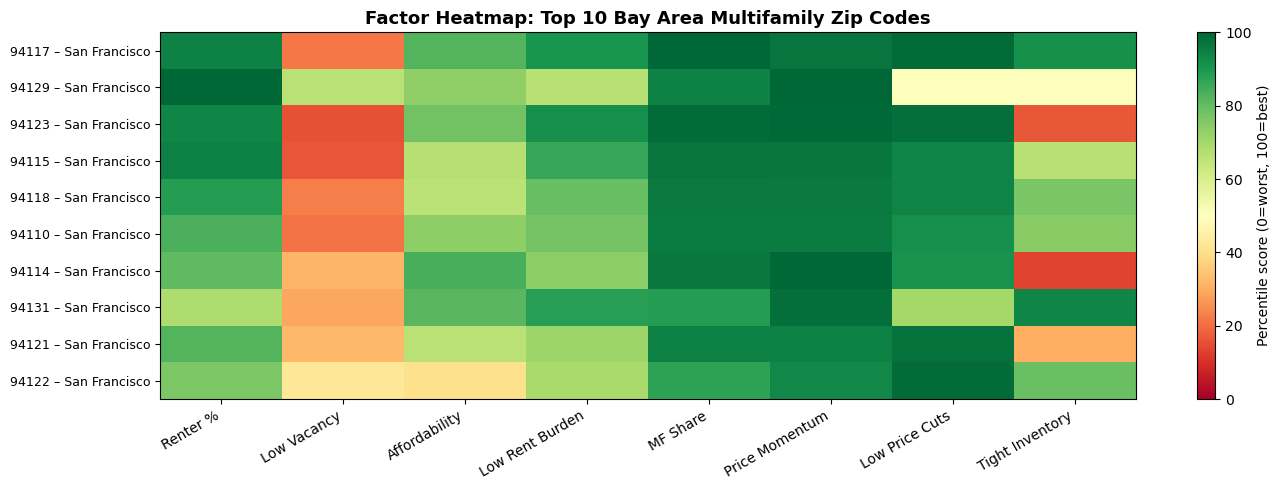

Saved factor heatmap


In [8]:
factor_cols = list(weights.keys())
factor_labels = [
    'Renter %', 'Low Vacancy', 'Affordability', 'Low Rent Burden',
    'MF Share', 'Price Momentum', 'Low Price Cuts', 'Tight Inventory'
]

top10 = scored.head(10).set_index('zip_code')[factor_cols]
top10.columns = factor_labels

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(top10.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
ax.set_xticks(range(len(factor_labels)))
ax.set_xticklabels(factor_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(
    [f"{z} – {scored[scored['zip_code']==z]['City'].values[0]}" for z in top10.index],
    fontsize=9
)
plt.colorbar(im, ax=ax, label='Percentile score (0=worst, 100=best)')
ax.set_title('Factor Heatmap: Top 10 Bay Area Multifamily Zip Codes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'charts/factor_heatmap_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved factor heatmap')

## 5. County-level summary

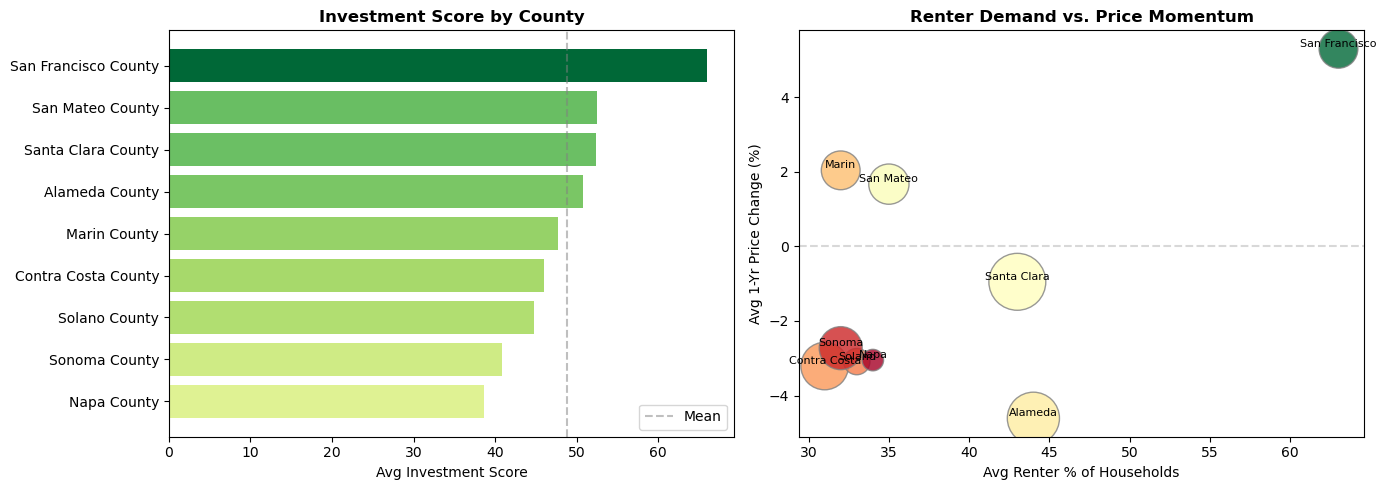

In [9]:
county_summary = scored.groupby('CountyName').agg(
    zip_count=('zip_code','count'),
    avg_score=('investment_score','mean'),
    median_rent=('median_contract_rent','median'),
    avg_renter_pct=('renter_pct','mean'),
    avg_vacancy=('vacancy_rate','mean'),
    avg_price_chg_1yr=('price_chg_1yr_pct','mean'),
    avg_price_latest=('price_latest','mean'),
).sort_values('avg_score', ascending=False).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counties = county_summary.index.tolist()
scores = county_summary['avg_score'].values
colors = cm.RdYlGn(scores / scores.max())

axes[0].barh(counties[::-1], scores[::-1], color=colors[::-1])
axes[0].set_xlabel('Avg Investment Score')
axes[0].set_title('Investment Score by County', fontweight='bold')
axes[0].axvline(scores.mean(), color='gray', linestyle='--', alpha=0.5, label='Mean')
axes[0].legend()

axes[1].scatter(
    county_summary['avg_renter_pct'] * 100,
    county_summary['avg_price_chg_1yr'],
    s=county_summary['zip_count'] * 30,
    c=scores, cmap='RdYlGn', alpha=0.8, edgecolors='gray'
)
for county, row in county_summary.iterrows():
    axes[1].annotate(
        county.replace(' County',''),
        (row['avg_renter_pct']*100, row['avg_price_chg_1yr']),
        fontsize=8, ha='center', va='bottom'
    )
axes[1].set_xlabel('Avg Renter % of Households')
axes[1].set_ylabel('Avg 1-Yr Price Change (%)')
axes[1].set_title('Renter Demand vs. Price Momentum', fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'charts/county_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Interactive choropleth map

In [10]:
# Fetch Bay Area zip code GeoJSON from Census TIGER
# We'll use the Census Cartographic Boundary Files (simplified, public domain)
print('Fetching Bay Area zip code boundaries...')
geo_url = 'https://raw.githubusercontent.com/OpenDataDE/State-zip-code-GeoJSON/master/ca_california_zip_codes_geo.min.json'

try:
    resp = requests.get(geo_url, timeout=60)
    resp.raise_for_status()
    ca_geo = resp.json()
    
    # Filter to Bay Area zips
    bay_zips_set = set(scored['zip_code'].dropna())
    bay_features = [
        f for f in ca_geo['features']
        if f['properties'].get('ZCTA5CE10') in bay_zips_set
        or f['properties'].get('zip') in bay_zips_set
    ]
    
    # Try common property names for zip code
    if not bay_features:
        sample_props = ca_geo['features'][0]['properties'] if ca_geo['features'] else {}
        print(f'GeoJSON zip property names: {list(sample_props.keys())}')
        zip_key = next((k for k in sample_props if 'zip' in k.lower() or 'zcta' in k.lower()), None)
        if zip_key:
            bay_features = [f for f in ca_geo['features'] if f['properties'].get(zip_key) in bay_zips_set]
    
    bay_geo = {'type': 'FeatureCollection', 'features': bay_features}
    print(f'  {len(bay_features)} Bay Area zip polygons found')
    
    # Save for reuse
    with open(DATA / 'bay_area_zips.geojson', 'w') as f:
        json.dump(bay_geo, f)
    
    geo_loaded = True
except Exception as e:
    print(f'GeoJSON fetch failed: {e}')
    geo_loaded = False

Fetching Bay Area zip code boundaries...


  271 Bay Area zip polygons found


In [11]:
if geo_loaded and bay_features:
    # Detect zip key in GeoJSON
    sample_props = bay_features[0]['properties']
    zip_key = next(
        (k for k in sample_props if 'zcta' in k.lower()),
        next((k for k in sample_props if 'zip' in k.lower()), list(sample_props.keys())[0])
    )
    print(f'Using GeoJSON zip key: "{zip_key}"')
    
    m = folium.Map(location=[37.7, -122.2], zoom_start=9, tiles='CartoDB positron')
    
    scored_for_map = scored[['zip_code','City','CountyName','investment_score',
                              'renter_pct','vacancy_rate','price_chg_1yr_pct',
                              'median_contract_rent','price_latest']].copy()
    scored_for_map = scored_for_map.dropna(subset=['investment_score'])
    
    choropleth = folium.Choropleth(
        geo_data=bay_geo,
        name='Investment Score',
        data=scored_for_map,
        columns=['zip_code', 'investment_score'],
        key_on=f'feature.properties.{zip_key}',
        fill_color='RdYlGn',
        fill_opacity=0.7,
        line_opacity=0.3,
        legend_name='Multifamily Investment Score (0-100)',
        bins=8,
    ).add_to(m)
    
    # Add tooltip data
    choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(
            fields=[zip_key],
            aliases=['ZIP:'],
            localize=True
        )
    )
    
    # Add circle markers for top 20 zips
    for _, row in scored_for_map.head(20).iterrows():
        # Try to get centroid from GeoJSON
        matching = [f for f in bay_features if f['properties'].get(zip_key) == row['zip_code']]
        if matching:
            coords = matching[0]['geometry']['coordinates']
            if matching[0]['geometry']['type'] == 'Polygon':
                lons = [c[0] for c in coords[0]]
                lats = [c[1] for c in coords[0]]
            else:  # MultiPolygon
                lons = [c[0] for ring in coords[0] for c in ring]
                lats = [c[1] for ring in coords[0] for c in ring]
            lat, lon = np.mean(lats), np.mean(lons)
            
            popup_html = f"""
            <b>ZIP {row['zip_code']} – {row['City']}</b><br>
            Investment Score: <b>{row['investment_score']:.1f}</b><br>
            Renter %: {row['renter_pct']:.1%}<br>
            Vacancy: {row['vacancy_rate']:.1%}<br>
            Median Rent: ${row['median_contract_rent']:,.0f}/mo<br>
            1yr Price Chg: {row['price_chg_1yr_pct']:+.1f}%
            """
            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                color='darkgreen',
                fill=True,
                fill_opacity=0.8,
                popup=folium.Popup(popup_html, max_width=200),
                tooltip=f"#{scored_for_map[scored_for_map['zip_code']==row['zip_code']].index[0]+1} {row['zip_code']}"
            ).add_to(m)
    
    folium.LayerControl().add_to(m)
    map_path = OUT / 'maps/market_selection_map.html'
    m.save(str(map_path))
    print(f'Map saved to {map_path}')
    m
else:
    print('Skipping map — GeoJSON not loaded')

Using GeoJSON zip key: "ZCTA5CE10"


Map saved to ../outputs/maps/market_selection_map.html


## 7. Rent control exposure by county

Bay Area has heavy rent control. Key jurisdictions:  
- **San Francisco**: All residential rentals built before 1979  
- **Oakland**: All rentals built before 1983  
- **San Jose**: Multi-family built before 1979 (>2 units)  
- **Berkeley, East Palo Alto, Mountain View, Richmond**: Covered

In [12]:
# Rent control flag (by city — rough but useful for screening)
rent_control_cities = {
    'San Francisco': 'Strong (pre-1979)',
    'Oakland': 'Strong (pre-1983)',
    'Berkeley': 'Strong (pre-1980)',
    'San Jose': 'Moderate (pre-1979, 2+ units)',
    'East Palo Alto': 'Strong',
    'Mountain View': 'Moderate',
    'Richmond': 'Moderate',
    'Hayward': 'Limited',
    'Union City': 'Limited',
}

scored['rent_control'] = scored['City'].map(rent_control_cities).fillna('None / Costa-Hawkins only')

rc_summary = scored.groupby('rent_control').agg(
    zip_count=('zip_code','count'),
    avg_score=('investment_score','mean'),
    median_rent=('median_contract_rent','median'),
    avg_renter_pct=('renter_pct','mean'),
).sort_values('avg_score', ascending=False).round(2)

print('Investment score by rent control status:')
rc_summary

Investment score by rent control status:


,zip_count,avg_score,median_rent,avg_renter_pct
rent_control,,,,
Strong (pre-1979),26,66.03,2393.0,0.63
Moderate,8,56.23,1877.5,0.50
Strong (pre-1980),8,55.93,1999.0,0.51
Strong (pre-1983),12,53.95,1643.0,0.58
"Moderate (pre-1979, 2+ units)",28,48.63,2413.0,0.43
Strong,1,48.01,2357.0,0.43
None / Costa-Hawkins only,186,47.32,2193.0,0.34
Limited,5,44.57,2140.0,0.39


## 8. Export final rankings

In [13]:
export_cols = [
    'rank','zip_code','City','CountyName','investment_score',
    'renter_pct','vacancy_rate','multifamily_share',
    'median_contract_rent','median_household_income',
    'rent_to_income_ratio','rent_burden_rate',
    'price_latest','price_chg_1yr_pct','price_chg_3yr_pct',
    'price_cut_rate','inv_chg_6m_pct','rent_control'
]
final = scored[[c for c in export_cols if c in scored.columns]]
final.to_csv(OUT / 'tables/market_selection_ranked.csv', index=False)
print(f'Exported {len(final)} zip codes to outputs/tables/market_selection_ranked.csv')

print('\n=== SUMMARY ===')
print(f'Total Bay Area zip codes analyzed: {len(scored)}')
print(f'Zip codes with full data: {scored["renter_pct"].notna().sum()}')
print(f'\nTop 5 markets:')
for _, row in scored.head(5).iterrows():
    rc = row.get('rent_control', 'N/A')
    print(f"  #{int(row['rank'])} {row['zip_code']} ({row['City']}, {row['CountyName'].replace(' County','')}) — "
          f"Score: {row['investment_score']:.1f} | "
          f"Renter: {row['renter_pct']:.1%} | "
          f"Rent ctrl: {rc}")

Exported 274 zip codes to outputs/tables/market_selection_ranked.csv

=== SUMMARY ===
Total Bay Area zip codes analyzed: 274
Zip codes with full data: 273

Top 5 markets:
  #1 94117 (San Francisco, San Francisco) — Score: 82.6 | Renter: 73.7% | Rent ctrl: Strong (pre-1979)
  #2 94129 (San Francisco, San Francisco) — Score: 79.1 | Renter: 100.0% | Rent ctrl: Strong (pre-1979)
  #3 94123 (San Francisco, San Francisco) — Score: 77.3 | Renter: 71.5% | Rent ctrl: Strong (pre-1979)
  #4 94115 (San Francisco, San Francisco) — Score: 77.0 | Renter: 74.4% | Rent ctrl: Strong (pre-1979)
  #5 94118 (San Francisco, San Francisco) — Score: 76.1 | Renter: 64.2% | Rent ctrl: Strong (pre-1979)
